In [1]:
from google.colab import drive
import os

# Montar o Google Drive
drive.mount('/content/drive')

# Definir e verificar caminhos
PATH_BASE = '/content/drive/MyDrive/Projeto_Bois_IA'
PATH_IMGS = os.path.join(PATH_BASE, 'back view')
PATH_EXCEL = os.path.join(PATH_BASE, 'measurements.xlsx')

if os.path.exists(PATH_IMGS) and os.path.exists(PATH_EXCEL):
    print("✅ Sucesso: Pastas e arquivos encontrados no Drive!")
else:
    print("❌ Erro: Verifique se os nomes das pastas no Drive estão corretos.")

Mounted at /content/drive
✅ Sucesso: Pastas e arquivos encontrados no Drive!


In [2]:
import cv2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

def preparar_dados():
    # 1. Carregar o Excel
    df = pd.read_excel(PATH_EXCEL)

    imagens = []
    pesos = []

    print(f"🔄 Carregando imagens de: {PATH_IMGS}...")

    # 2. Loop para carregar as 72 imagens (.png)
    for i in range(1, 73):
        img_nome = f"{i}.png"
        img_path = os.path.join(PATH_IMGS, img_nome)

        img = cv2.imread(img_path)

        if img is not None:
            # Converter BGR para RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Redimensionar para 128x128
            img = cv2.resize(img, (128, 128))
            # Normalizar pixels (0 a 1)
            img = img / 255.0

            imagens.append(img)
            # Usando o nome correto da coluna que você informou
            peso = df.iloc[i-1]['Body weight (kg)']
            pesos.append(peso)
        else:
            print(f"⚠️ Aviso: Não encontrei a imagem {img_nome}")

    # Converter para formato que a IA entende (Numpy Arrays)
    X = np.array(imagens)
    y = np.array(pesos)

    # 3. Dividir em Treino (80%) e Teste (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("-" * 30)
    print(f"✅ Concluído! Total: {len(X)} imagens.")
    print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")
    print("-" * 30)

    return X_train, X_test, y_train, y_test

# EXECUTAR A FUNÇÃO E GUARDAR OS DADOS NAS VARIÁVEIS
X_train, X_test, y_train, y_test = preparar_dados()

🔄 Carregando imagens de: /content/drive/MyDrive/Projeto_Bois_IA/back view...
⚠️ Aviso: Não encontrei a imagem 50.png
------------------------------
✅ Concluído! Total: 71 imagens.
Treino: 56 | Teste: 15
------------------------------


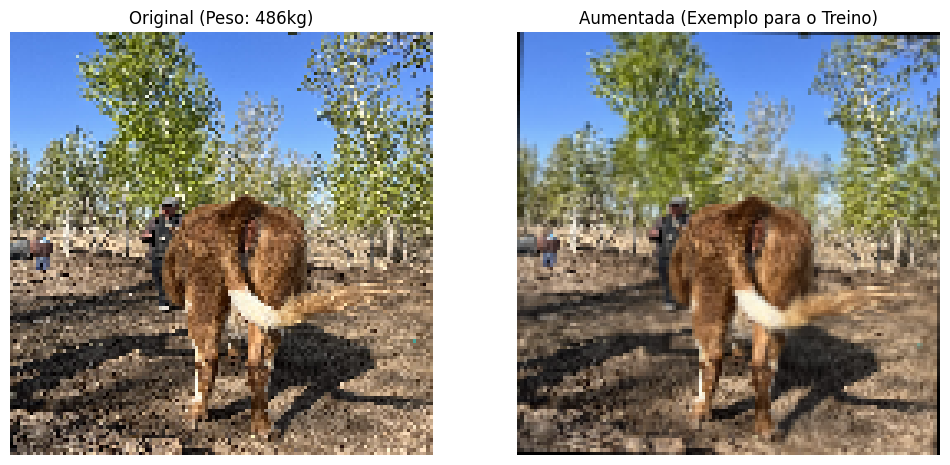

In [3]:
import albumentations as A
import matplotlib.pyplot as plt

# Definir as transformações de aumento
transformador = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Rotate(limit=15, p=0.5),
])

# Escolher o primeiro boi do treino para testar
imagem_original = X_train[0]
peso_original = y_train[0]

# Aplicar o aumento (Data Augmentation)
# Nota: O Albumentations espera imagens em 0-255 ou float. Como já normalizamos, passamos direto.
imagem_aumentada = transformador(image=imagem_original)['image']

# Mostrar os resultados lado a lado
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(imagem_original)
plt.title(f"Original (Peso: {peso_original}kg)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagem_aumentada)
plt.title("Aumentada (Exemplo para o Treino)")
plt.axis('off')

plt.show()

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

def criar_modelo():
    # 1. Carregamos a MobileNetV2 pré-treinada (sem a camada de classificação final)
    # Usamos o tamanho 128x128 que definimos no carregamento dos dados
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(128, 128, 3),
        include_top=False,
        weights='imagenet'
    )

    # Congelamos as camadas da base para não perder o que ela já aprendeu
    base_model.trainable = False

    # 2. Criamos as novas camadas para o teu problema específico (Prever Peso)
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), # Achata as características da imagem
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),             # Ajuda a evitar que a IA "decore" as fotos (Overfitting)
        layers.Dense(1)                  # Saída única: O valor numérico do peso
    ])

    # 3. Compilação do Modelo
    # optimizer='adam' ajusta os pesos automaticamente
    # loss='mae' (Mean Absolute Error) mostra o erro médio em Kg
    model.compile(optimizer='adam', loss='mae', metrics=['mse'])

    return model

# Instanciar o modelo
modelo_bois = criar_modelo()
modelo_bois.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

🚀 A iniciar o treino na GPU do Colab...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 510ms/step - loss: 476.1978 - mse: 234591.2969 - val_loss: 441.1243 - val_mse: 198962.1562
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - loss: 454.6560 - mse: 214577.1094 - val_loss: 416.7806 - val_mse: 178030.6719
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - loss: 426.9180 - mse: 190626.4844 - val_loss: 389.3095 - val_mse: 155858.5781
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - loss: 397.5619 - mse: 166271.6562 - val_loss: 359.0948 - val_mse: 133239.0938
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 364.0460 - mse: 140899.8438 - val_loss: 325.8553 - val_mse: 110497.7969
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 327.7735 - mse: 115920.3516 - val_loss: 289.5533 - val_mse: 88223.2109
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 288.6996 - mse: 92762.3672 - val_loss: 250.0030 - val_mse: 67000.6250
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - l

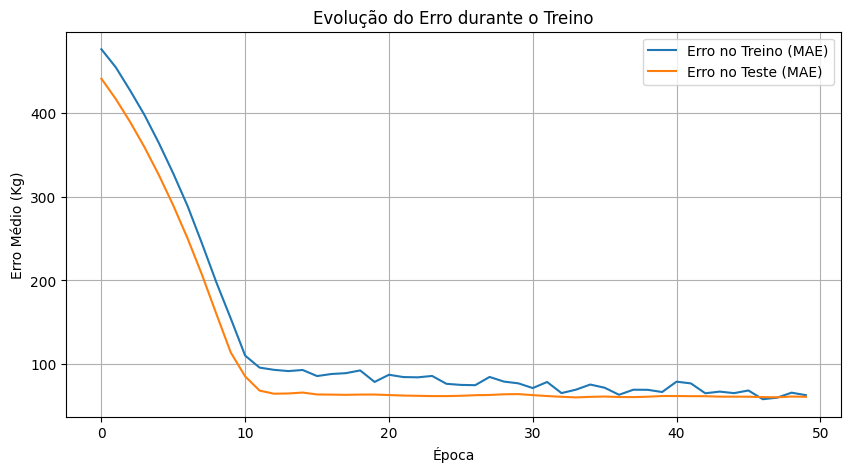

In [7]:
import matplotlib.pyplot as plt

print("🚀 A iniciar o treino na GPU do Colab...")

# O 'fit' é onde a aprendizagem acontece
# epochs=50: O modelo vai olhar para o conjunto de dados 50 vezes
historico = modelo_bois.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=8,
    verbose=1
)

print("\n✅ Treino concluído!")

# --- Visualizar a evolução do erro ---
plt.figure(figsize=(10, 5))
plt.plot(historico.history['loss'], label='Erro no Treino (MAE)')
plt.plot(historico.history['val_loss'], label='Erro no Teste (MAE)')
plt.title('Evolução do Erro durante o Treino')
plt.xlabel('Época')
plt.ylabel('Erro Médio (Kg)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
import numpy as np

# 1. Fazer previsões para o conjunto de teste
previsoes = modelo_bois.predict(X_test)

# 2. Mostrar os resultados para os primeiros 5 bois do teste
print("--- RESULTADOS DA PREVISÃO ---")
for i in range(5):
    peso_real = y_test[i]
    peso_predito = previsoes[i][0]
    erro = abs(peso_real - peso_predito)

    print(f"Boi {i+1}: Real: {peso_real:.1f}kg | IA: {peso_predito:.1f}kg | Erro: {erro:.1f}kg")

# 3. Mostrar o Erro Médio Absoluto Final
erro_medio = np.mean(np.abs(y_test - previsoes.flatten()))
print(f"\n📊 Erro Médio Final no conjunto de teste: {erro_medio:.2f} kg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
--- RESULTADOS DA PREVISÃO ---
Boi 1: Real: 362.0kg | IA: 430.9kg | Erro: 68.9kg
Boi 2: Real: 545.0kg | IA: 477.9kg | Erro: 67.1kg
Boi 3: Real: 450.0kg | IA: 383.6kg | Erro: 66.4kg
Boi 4: Real: 448.0kg | IA: 370.9kg | Erro: 77.1kg
Boi 5: Real: 346.0kg | IA: 469.8kg | Erro: 123.8kg

📊 Erro Médio Final no conjunto de teste: 60.97 kg


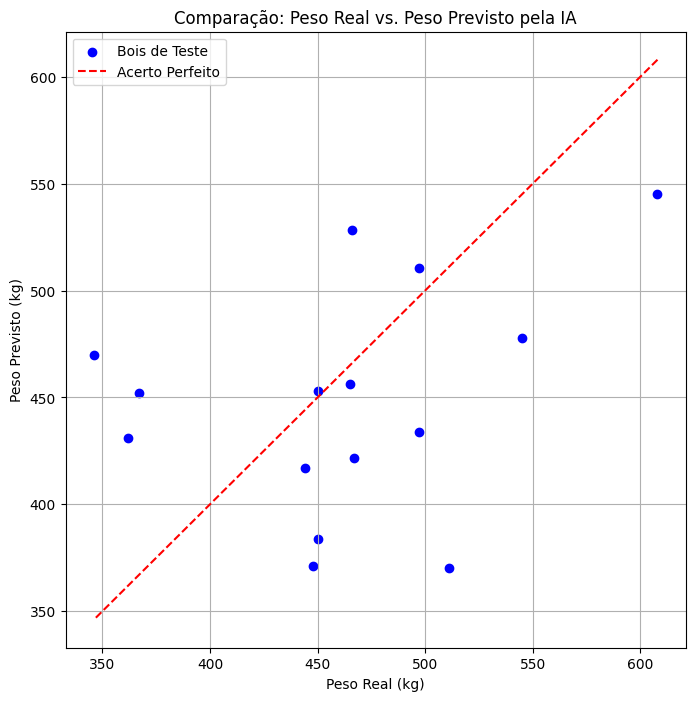

In [12]:
import matplotlib.pyplot as plt

# Criar o gráfico
plt.figure(figsize=(8, 8))
plt.scatter(y_test, previsoes, c='blue', label='Bois de Teste')

# Adicionar uma linha de 45 graus (A linha do acerto perfeito)
p1 = max(max(previsoes.flatten()), max(y_test))
p2 = min(min(previsoes.flatten()), min(y_test))
plt.plot([p1, p2], [p1, p2], 'r--', label='Acerto Perfeito')

plt.title('Comparação: Peso Real vs. Peso Previsto pela IA')
plt.xlabel('Peso Real (kg)')
plt.ylabel('Peso Previsto (kg)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
modelo_bois.save('modelo_peso_bois_v1.h5')
print("✅ Modelo guardado com sucesso!")

✅ Modelo guardado com sucesso!


In [14]:
from google.colab import files
modelo_bois.save('modelo_peso_bois.h5')
files.download('modelo_peso_bois.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 46.5 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
import cv2
from PIL import Image
import sqlite3
from datetime import datetime
import pandas as pd
import os

# --- CONFIGURAÇÕES DE CAMINHO ---
# O banco de dados será salvo na sua pasta do Projeto no Drive
DB_PATH = '/content/drive/MyDrive/Projeto_Bois_IA/monitoramento_bois.db'
MODEL_PATH = 'modelo_peso_bois_v1.h5'

def init_db():
    """Inicializa o banco de dados SQLite no Drive"""
    conn = sqlite3.connect(DB_PATH)
    c = conn.cursor()
    c.execute('''CREATE TABLE IF NOT EXISTS pesagens
                 (id INTEGER PRIMARY KEY AUTOINCREMENT,
                  brinco_id TEXT,
                  data TEXT,
                  peso_estimado REAL)''')
    conn.commit()
    conn.close()

@st.cache_resource
def load_model_ia():
    """Carrega o modelo treinado com correção de erro de compilação"""
    # Carrega apenas os pesos e arquitetura (ignora erros de otimizador do Keras)
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    # Re-compila para permitir o uso de métricas se necessário
    model.compile(optimizer='adam', loss='mae')
    return model

# --- INTERFACE STREAMLIT ---
st.set_page_config(page_title="Rayvora - Monitoramento UFSC", layout="wide")

# Inicializar recursos
if os.path.exists(MODEL_PATH):
    model = load_model_ia()
    init_db()
else:
    st.error(f"Arquivo {MODEL_PATH} não encontrado! Certifique-se de que salvou o modelo no Colab.")

st.title("📊 Sistema de Monitoramento de Gado - IA (Rayvora)")
st.markdown("Desenvolvido para o Projeto Integrador - UFSC Araranguá")

# Menu Lateral
menu = ["Nova Pesagem", "Histórico do Rebanho"]
escolha = st.sidebar.selectbox("Navegação", menu)

if escolha == "Nova Pesagem":
    st.header("⚖️ Estimativa de Peso em Tempo Real")

    col1, col2 = st.columns(2)

    with col1:
        brinco = st.text_input("Identificação do Animal (Brinco/ID):", "Boi_001")
        foto = st.file_uploader("Carregar foto da traseira (Back View)", type=['png', 'jpg', 'jpeg'])

    if foto is not None:
        img_original = Image.open(foto).convert('RGB')

        with col2:
            st.image(img_original, caption="Foto para análise", width=350)

        if st.button("🚀 Calcular Peso"):
            # Pré-processamento (Igual ao Treino)
            img_arr = np.array(img_original)
            img_res = cv2.resize(img_arr, (128, 128))
            img_normalized = img_res / 255.0
            img_input = np.expand_dims(img_normalized, axis=0)

            # Predição
            with st.spinner('A IA está analisando a carcaça...'):
                predicao = model.predict(img_input)
                peso_final = float(predicao[0][0])

            st.success(f"**Resultado:** O peso estimado é de **{peso_final:.2f} kg**")

            # Salvar no Banco de Dados (SQLite no Drive)
            try:
                conn = sqlite3.connect(DB_PATH)
                c = conn.cursor()
                agora = datetime.now().strftime("%d/%m/%Y %H:%M:%S")
                c.execute("INSERT INTO pesagens (brinco_id, data, peso_estimado) VALUES (?, ?, ?)",
                          (brinco, agora, peso_final))
                conn.commit()
                conn.close()
                st.info("✅ Dados registrados no histórico do Drive.")
            except Exception as e:
                st.error(f"Erro ao salvar no banco: {e}")

elif escolha == "Histórico do Rebanho":
    st.header("📈 Relatório de Pesagens")

    if os.path.exists(DB_PATH):
        conn = sqlite3.connect(DB_PATH)
        df = pd.read_sql_query("SELECT brinco_id as 'ID Animal', data as 'Data/Hora', peso_estimado as 'Peso (kg)' FROM pesagens ORDER BY id DESC", conn)
        conn.close()

        if not df.empty:
            st.dataframe(df, use_container_width=True)

            # Exportar para Excel (opcional)
            csv = df.to_csv(index=False).encode('utf-8')
            st.download_button("📥 Baixar Relatório (CSV)", csv, "relatorio_bois.csv", "text/csv")
        else:
            st.warning("Nenhum registro encontrado no banco de dados.")
    else:
        st.error("Banco de dados ainda não foi criado. Faça uma pesagem primeiro.")

Overwriting app.py


In [ ]:
from pyngrok import ngrok

# COLOQUE SEU TOKEN AQUI ENTRE AS ASPAS
NGROK_TOKEN = "3CbUDua9wx9sq5dhdc3nVoId3uh_cpQEbs3AAxBAUg85vb2t"
ngrok.set_auth_token(NGROK_TOKEN)

# Abrir o túnel e rodar o app
public_url = ngrok.connect(8501).public_url
print(f"🔗 ACESSE SEU APP AQUI: {public_url}")

!streamlit run app.py --server.port 8501

🔗 ACESSE SEU APP AQUI: https://unify-crawling-irate.ngrok-free.dev



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.118.71.142:8501

2026-04-20 02:58:49.240569: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776653929.267070   62192 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776653929.274710   62192 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776653929.293826   62192 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:177665

In [1]:
!cp modelo_peso_bois_v1.h5 /content/drive/MyDrive/Projeto_Bois_IA/

cp: cannot stat 'modelo_peso_bois_v1.h5': No such file or directory
